# Optimize driving efficiency — **per-dataset diagnostic dashboards**

This notebook rebuilds the same **2×2 dashboard** figures as `results/dashboards/ds*_diagnostics_dashboard.png`, one dataset at a time. **Interpretation and conclusions** for DS2, DS4, DS5, and the cross-dataset view are written in the markdown cells **below each figure**.

**Run from repo root** (`ML-EV-Energy-Consumption`) so paths resolve, or adjust `PROJECT_ROOT` in the next cell.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for p in [_cwd, *_cwd.parents]:
    if (p / "data" / "processed").is_dir():
        PROJECT_ROOT = p
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Set cwd to repo root or fix PROJECT_ROOT.")

colors = {"Random Forest": "#4C72B0", "Gradient Boosting": "#DD8452", "Ridge": "#55A868"}
models = ["Random Forest", "Gradient Boosting", "Ridge"]

sources = [
    ("Random Forest", PROJECT_ROOT / "optimize_efficiency_rf_results_comparison.csv"),
    ("Gradient Boosting", PROJECT_ROOT / "optimize_efficiency_gb_results_comparison.csv"),
    ("Ridge", PROJECT_ROOT / "optimize_efficiency_ridge_results_comparison.csv"),
]

frames = []
for model, path in sources:
    df = pd.read_csv(path)
    df["Model"] = model
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
all_df["DatasetShort"] = all_df["Dataset"].replace(
    {
        "Dataset 2 (EV specs -> Efficiency)": "DS2",
        "Dataset 4 (EV charging -> Charging Cost)": "DS4",
        "Dataset 5 (EV energy -> kWh)": "DS5",
    }
)

required = ["Train_RMSE", "Val_RMSE", "Test_RMSE", "Train_R2", "Val_R2", "Test_R2", "Total_s"]
missing = [c for c in required if c not in all_df.columns]
if missing:
    raise ValueError(
        f"CSV missing columns {missing}. Run the model scripts once so comparison CSVs include train/val metrics."
    )

print("Project root:", PROJECT_ROOT)
print(all_df[["DatasetShort", "Model", "Test_RMSE", "Test_R2"]].to_string(index=False))

Project root: /Users/ew/Documents/MSE 446/ML-EV-Energy-Consumption
DatasetShort             Model  Test_RMSE   Test_R2
         DS2     Random Forest  21.966556  0.577102
         DS4     Random Forest  11.073401 -0.097007
         DS5     Random Forest   1.412364  0.588641
         DS2 Gradient Boosting  18.860252  0.688250
         DS4 Gradient Boosting  11.406798 -0.164058
         DS5 Gradient Boosting   1.419965  0.584202
         DS2             Ridge  14.548038  0.814510
         DS4             Ridge  10.633020 -0.011487
         DS5             Ridge   1.383534  0.605263


In [2]:
def plot_dataset_dashboard(ds_key: str, title_suffix: str = ""):
    """2×2 panel: R² by split, RMSE by split, gap indicators, runtime."""
    sub = (
        all_df[all_df["DatasetShort"] == ds_key]
        .set_index("Model")
        .loc[models]
        .reset_index()
    )

    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Optimize Driving Efficiency — {ds_key} {title_suffix}".strip(),
        fontsize=14,
        fontweight="bold",
    )

    x = np.arange(len(models))
    w = 0.25

    ax = axs[0, 0]
    ax.bar(x - w, sub["Train_R2"], width=w, label="Train", color="#4C72B0", alpha=0.9)
    ax.bar(x, sub["Val_R2"], width=w, label="Val", color="#DD8452", alpha=0.9)
    ax.bar(x + w, sub["Test_R2"], width=w, label="Test", color="#55A868", alpha=0.9)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title("R² by model & split")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10)
    ax.set_ylabel("R²")
    ax.legend(fontsize=8)

    ax = axs[0, 1]
    ax.bar(x - w, sub["Train_RMSE"], width=w, label="Train", color="#4C72B0", alpha=0.9)
    ax.bar(x, sub["Val_RMSE"], width=w, label="Val", color="#DD8452", alpha=0.9)
    ax.bar(x + w, sub["Test_RMSE"], width=w, label="Test", color="#55A868", alpha=0.9)
    ax.set_title("RMSE by model & split (lower better)")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10)
    ax.set_ylabel("RMSE")
    ax.legend(fontsize=8)

    ax = axs[1, 0]
    gap_r2 = sub["Train_R2"] - sub["Test_R2"]
    rmse_ratio = sub["Test_RMSE"] / sub["Train_RMSE"]
    ax.bar(x - w / 2, gap_r2, width=w, label="Train−Test R² gap", color="#8172B3")
    ax.bar(x + w / 2, rmse_ratio, width=w, label="Test/Train RMSE ratio", color="#937860")
    ax.set_title("Generalization gap indicators")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10)
    ax.legend(fontsize=8)

    ax = axs[1, 1]
    ax.bar(x, sub["Total_s"], color=[colors[m] for m in models])
    ax.set_title("Runtime (Total_s)")
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10)
    ax.set_ylabel("Seconds")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def plot_cross_dataset_dashboard():
    """2×2: grouped test RMSE/R², heatmap, average rank — same as cross_dataset png."""
    datasets = ["DS2", "DS4", "DS5"]
    fig, axs = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle(
        "Optimize Driving Efficiency — cross-dataset model comparison",
        fontsize=15,
        fontweight="bold",
    )

    X = np.arange(len(datasets))
    w = 0.24

    ax = axs[0, 0]
    for i, m in enumerate(models):
        vals = [
            float(
                all_df[(all_df["DatasetShort"] == d) & (all_df["Model"] == m)][
                    "Test_RMSE"
                ].iloc[0]
            )
            for d in datasets
        ]
        ax.bar(X + (i - 1) * w, vals, width=w, label=m, color=colors[m])
    ax.set_title("Test RMSE by dataset and model")
    ax.set_xticks(X)
    ax.set_xticklabels(datasets)
    ax.set_ylabel("Test RMSE")
    ax.legend(fontsize=8)

    ax = axs[0, 1]
    for i, m in enumerate(models):
        vals = [
            float(
                all_df[(all_df["DatasetShort"] == d) & (all_df["Model"] == m)][
                    "Test_R2"
                ].iloc[0]
            )
            for d in datasets
        ]
        ax.bar(X + (i - 1) * w, vals, width=w, label=m, color=colors[m])
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_title("Test R² by dataset and model")
    ax.set_xticks(X)
    ax.set_xticklabels(datasets)
    ax.set_ylabel("Test R²")
    ax.legend(fontsize=8)

    ax = axs[1, 0]
    piv = all_df.pivot(index="DatasetShort", columns="Model", values="Test_R2").loc[
        datasets, models
    ]
    im = ax.imshow(piv.values, cmap="YlGnBu", aspect="auto")
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models, rotation=15)
    ax.set_yticks(np.arange(len(datasets)))
    ax.set_yticklabels(datasets)
    ax.set_title("Test R² heatmap")
    for i in range(len(datasets)):
        for j in range(len(models)):
            ax.text(
                j,
                i,
                f"{piv.values[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )
    fig.colorbar(im, ax=ax, fraction=0.046)

    ax = axs[1, 1]
    rank_df = all_df.copy()
    rank_df["rmse_rank"] = rank_df.groupby("DatasetShort")["Test_RMSE"].rank(
        ascending=True, method="min"
    )
    rank_df["r2_rank"] = rank_df.groupby("DatasetShort")["Test_R2"].rank(
        ascending=False, method="min"
    )
    avg = rank_df.groupby("Model")[["rmse_rank", "r2_rank"]].mean().mean(axis=1).reindex(
        models
    )
    ax.bar(np.arange(len(models)), avg.values, color=[colors[m] for m in models])
    ax.set_xticks(np.arange(len(models)))
    ax.set_xticklabels(models, rotation=10)
    ax.set_title("Average rank (lower better)")
    ax.set_ylabel("Rank")
    for i, v in enumerate(avg.values):
        ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

## DS2 — EV specs → Efficiency (Wh/km)

Dashboard below; **conclusions** are in the next cell.

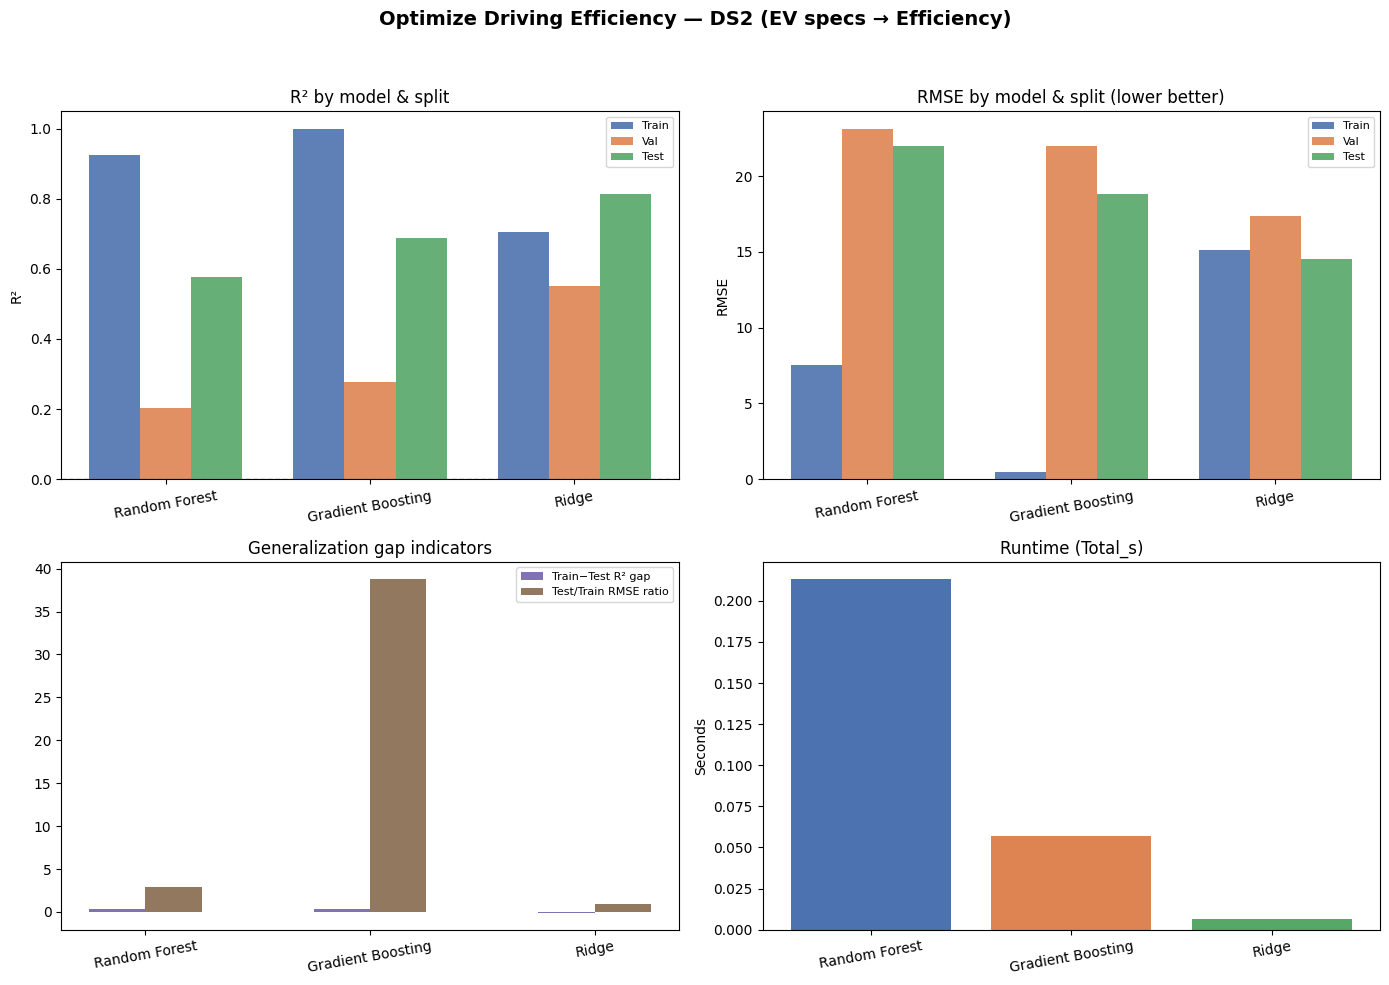

In [3]:
fig = plot_dataset_dashboard("DS2", "(EV specs → Efficiency)")
plt.show()

### Conclusions (DS2)

- **Signal:** Vehicle specs contain **usable predictive signal** for efficiency (Wh/km); the task is learnable in principle.
- **Overfitting:** **Random Forest** and **Gradient Boosting** show **very high train R²** and **much worse validation/test** (large train→val RMSE gap). That pattern matches **overfitting** on a **small catalog-style** sample—not trustworthy in-sample tree scores.
- **Best generalization:** **Ridge** stays more **balanced across train / validation / test** and in our runs achieves the **strongest test R² and lowest test RMSE** among the three models. Prefer **Ridge (or similar L2-regularized linear models)** for reporting or deployment on this dataset unless you add data or simplify features.

## DS4 — EV charging → Charging cost (USD)

Dashboard below; **conclusions** are in the next cell.

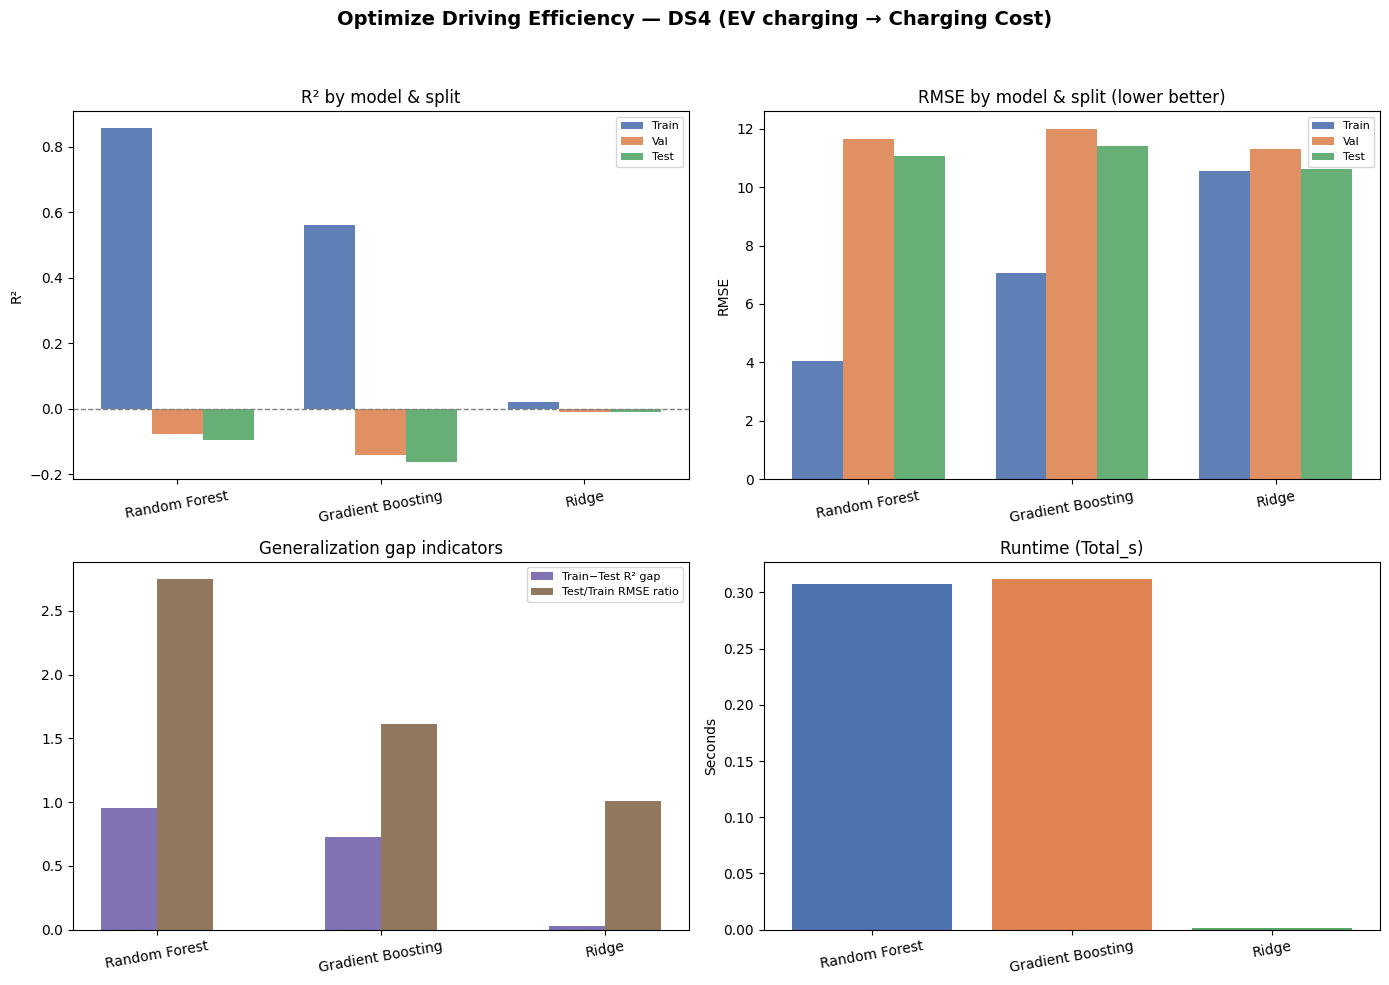

In [4]:
fig = plot_dataset_dashboard("DS4", "(EV charging → Charging Cost)")
plt.show()

### Conclusions (DS4)

- **Predictive power:** With the **current feature set**, **test R² is near zero or negative** for all three models (Ridge is essentially **flat** on train too). **High train R² on trees** that **collapses on val/test** means the fits **do not generalize**—not real skill out-of-sample.
- **Errors:** **Test MAPE** is very high (~55% in saved runs), so **relative cost predictions** are unreliable.
- **Interpretation:** Selected charging variables **do not explain** charging cost well; plausible gaps include **tariffs, region, time-of-use, taxes, session structure**, or misalignment between labels and features. **Do not** use these models for dependable **USD cost** prediction without richer inputs or reframing the target.

## DS5 — EV energy → Energy consumption (kWh)

Dashboard below; **conclusions** are in the next cell.

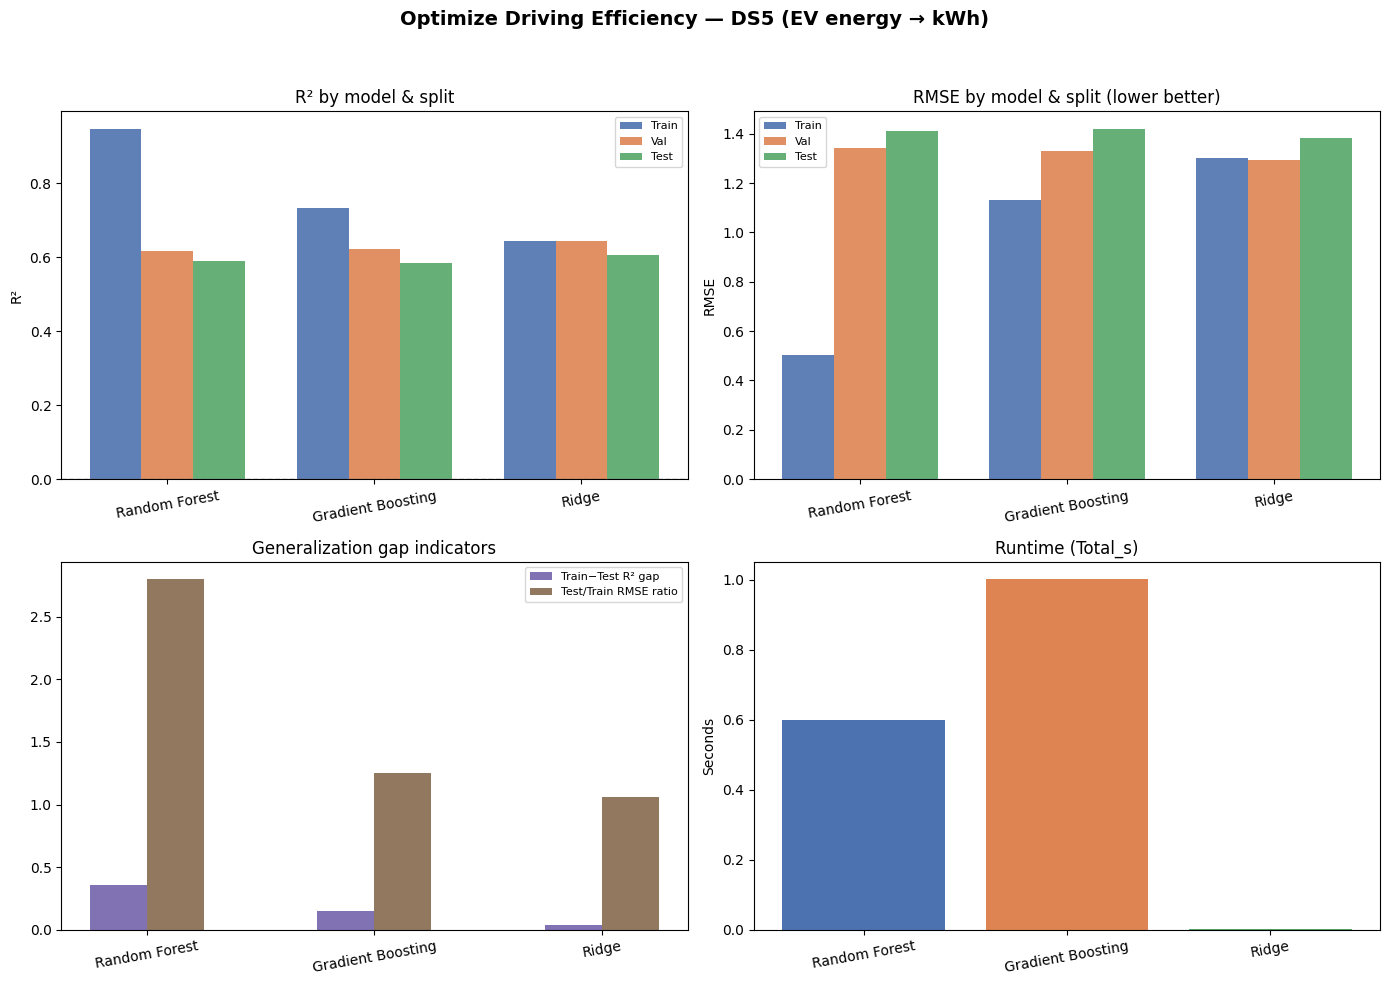

In [5]:
fig = plot_dataset_dashboard("DS5", "(EV energy → kWh)")
plt.show()

### Conclusions (DS5)

- **Use case:** DS5 is the dataset that matches **“optimize driving efficiency”** in practice: it predicts **energy used (kWh)** from **driving / trip–related** features. That is the outcome you usually care about for behavior and operations—even if another dataset scores higher on a pure **R²** comparison.
- **Numbers:** Test **R²** is **moderate** (~0.58–0.61 with Ridge in our runs)—**lower than DS2 (Ridge)** on test R², because predicting **real trip energy** from behavioral covariates is **noisier** than predicting **catalog efficiency (Wh/km) from vehicle specs**. So **DS5 is not “best” by raw R²**; it is **best aligned** with the driving-efficiency question.
- **Generalization:** **Validation and test** sit in the **same ballpark** for all three model families (unlike **DS2 trees**, which spike on train). **Ridge** is slightly best on test among DS5 models; ensembles are close.

## Cross-dataset comparison

Dashboard below compares **DS2, DS4, and DS5** on **test** metrics and average ranks; **conclusions** are in the next cell.

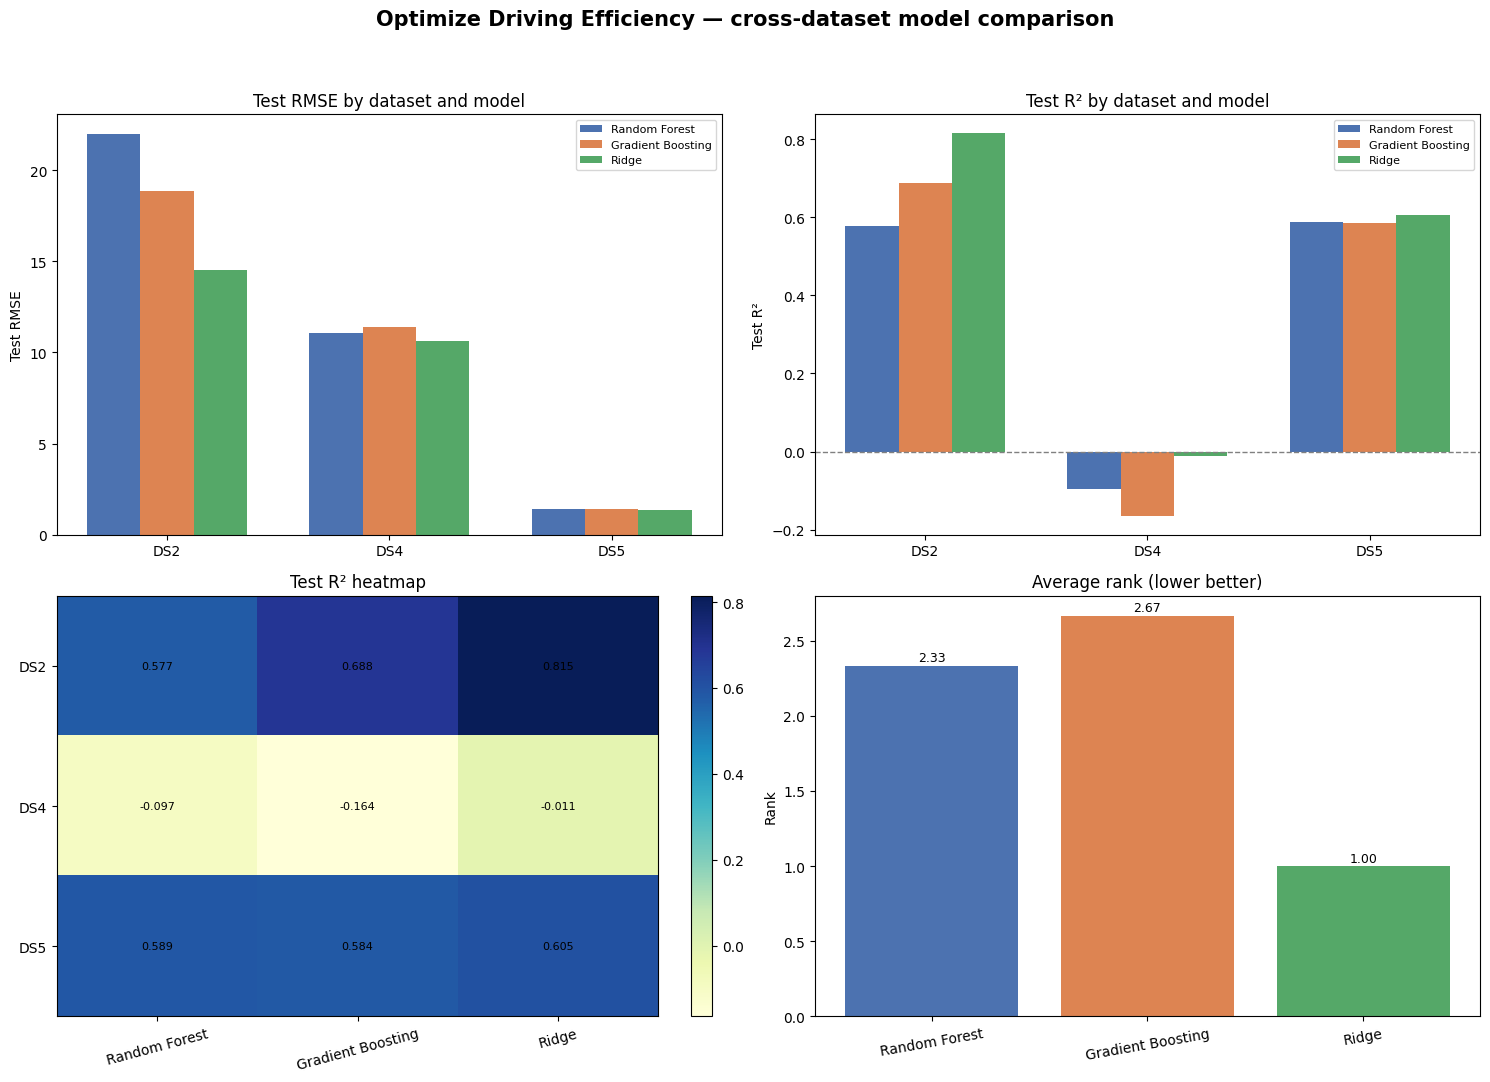

In [6]:
fig = plot_cross_dataset_dashboard()
plt.show()

### Conclusions (cross-dataset)

- **Ranking:** On **out-of-sample test** metrics, **Ridge** usually **beats** the tree ensembles on **RMSE** and **R²** (especially on **DS2**, where trees overfit). The **average-rank** panel summarizes this.
- **Highest test R²:** In these CSVs, **DS2 with Ridge** reaches the **largest test R²** (~0.81)—**not** DS5 (~0.61). Different **targets** and **noise levels** mean you should not expect DS5 to “win” on R² alone; **DS5 wins on relevance** (kWh from driving-style inputs).
- **DS4:** All models are **weak** on charging cost; the bottleneck is **features / problem definition**, not tuning.
- **Practical split:** **DS2** = best **numeric** fit for **specs → efficiency**; **DS5** = best **fit to the driving-efficiency narrative** (trip kWh); **DS4** = not usable for cost until **X** improves.